In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

25024
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]


System coefficients:
xi_x = 0.000
xi_y = 0.000

Nt: 1024
init. cond.:   0.50   0.50 




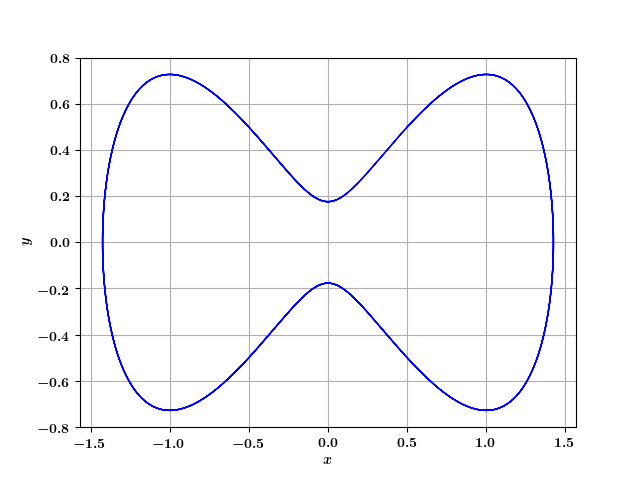

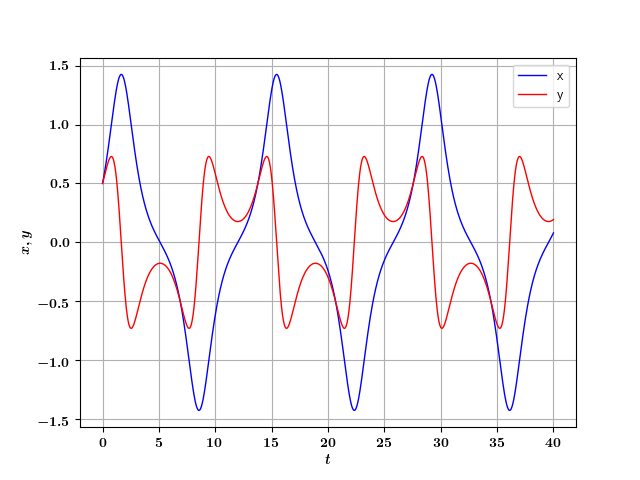

1025


In [295]:
# ---------------------------------------------------------------
# --- Prepare the system: Duffing oscillator ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 2  # the number of degrees of freedom
    F_terms, sys_coefs, return_sys, shift_coefs = None, None, None, None
    if sel_case == 0:

        # --- Initial conditions ---
        # x_init = np.array([0.0, 1.0])
        # x_init = np.array([0.0, 0.2])
        # x_init = np.array([0.1, 0.0])

        # x_init = np.array([-0.04, 0.0]) # complicated: for error analysis
        x_init = np.array([0.5, 0.5]) # complicated: for error analysis

        # --- Time grid ---
        # tmax, nt = 14, 8      # for some 2D plots
        tmax, nt = 40, 10  # for error analysis

        xi_x, xi_y = 0., 0.

        sys_coefs = {}
        sys_coefs["xi_x"]  = xi_x
        sys_coefs["xi_y"]  = xi_y

        def return_sys(ss):
            xi_x  = ss["xi_x"]  
            xi_y  = ss["xi_y"]  

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))
            
            F_terms[0][0,0] = xi_y
            F_terms[0][1,0] = xi_x  - xi_x**3

            F_terms[1][0, 1] = 1.
            F_terms[1][1, 0] = 1. - 3.*xi_x**2

            F_terms[2][1, 0] = - 3. * xi_x

            F_terms[3][1, 0] = - 1.
            return F_terms
        
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new
        
        print("\nSystem coefficients:")
        for key, value in sys_coefs.items():
            print("{:s} = {:0.3f}".format(key, value))
        print()

        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0, 1] * x[1],
            lambda x: F_terms[0][1,0] + F_terms[1][1, 0] * x[0] + F_terms[2][1, 0] * x[0]**2 + F_terms[3][1, 0] * x[0]**3,
        ]

    # ----------------------------------------------------
    return F, tmax, nt, Nx, x_init, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 0

N_nl_orig_ = 3 
F_, tmax_, nt_, Nx_, x_init_ref_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("Nt: {:d}".format(Nt_))
print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

print(len(t_ref_))

In [308]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(ca)
N_nl = 6   
flag_max_error_ = True
case_sim_ = "DU2D"
step_t_ = 1

X_GC_, Zeta_ = None, None

# # -----------------------------------------------------
# # --- Standard embedding ---
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, return_sys_(sys_coefs_))

# # -----------------------------------------------------
# # --- Dynamic Piecewise embedding ---
# zeta_th = 0.70
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global(
#     x_init_ref_, N_nl, N_nl_orig_, t_, 
#     sys_coefs_, return_sys_, shift_coefs_,
#     zeta_th = zeta_th
# )
# case_sim_ = "DU2D_xi{:0.3f}".format(zeta_th)
# del zeta_th


# -----------------------------------------------------
# --- Static embedding ---
# X_GC_ = np.array([0., 0.2])
X_GC_ = np.array([-0.0, 1.0])
# X_GC_ = np.array([-0.1, 0.0]) # one of the bests 

# Zeta_ = np.array([ 0.4 / np.sqrt(Nx_) ]*Nx_)
Zeta_ = np.array([ 0.1 / np.sqrt(Nx_) ]*Nx_)

case_sim_ = "DU2D_init{:0.1f}_{:0.1f}_GC{:0.1f}_{:0.1f}_xi{:0.3f}".format(
    x_init_ref_[0], x_init_ref_[1], X_GC_[0], X_GC_[1], Zeta_[0]
)

sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global_fixed(
    x_init_ref_, N_nl, N_nl_orig_, t_, 
    sys_coefs_, return_sys_, shift_coefs_,
    X_GC_, Zeta_
)
GCE_grid = ca.print_GCE_grid(X_GC_, Zeta_, max_v = 1.49)

The total number of variables in the embedding: 126

Done


 ----------------------------------------------
--- GCE grid ---
----------------------------------------------
center: 
    -0.000e+00      1.000e+00 
sizes: 
     7.071e-02      7.071e-02 

--- x ---
    -1.626e+00     -1.485e+00     -1.344e+00     -1.202e+00     -1.061e+00     -9.192e-01     -7.778e-01     -6.364e-01     -4.950e-01     -3.536e-01     -2.121e-01     -7.071e-02      7.071e-02      2.121e-01      3.536e-01      4.950e-01      6.364e-01      7.778e-01      9.192e-01      1.061e+00      1.202e+00      1.344e+00      1.485e+00      1.697e+00 
--- y ---
     3.636e-01      5.050e-01      6.464e-01      7.879e-01      9.293e-01      1.071e+00      1.212e+00      1.354e+00      1.495e+00      1.707e+00 


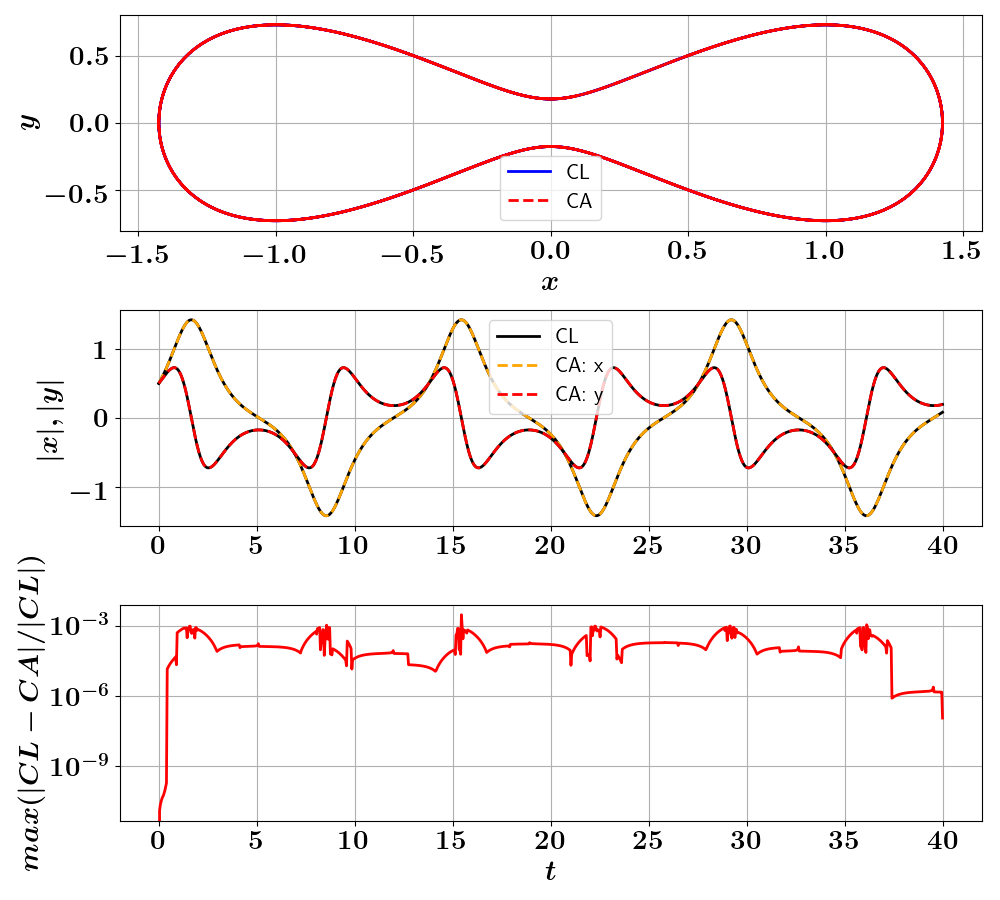

In [307]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(
    t_ref_, sol_ref_, t_emb_, sol_emb_,
    flag_save = False, 
    path_save = path_save_, 
    case_title = case_sim_, case_emb = case_emb_,
    fontsize = 20, fig_size = (10,9),
    flag_var_semilogy = False,
    step_t = step_t_,
    flag_max_error = flag_max_error_
)